# Section 1: Dataset structure & loading

Firstly, we import the required Python libraries required for this EDA.

We then, load the dataset iteratively into 3 different pandas dataframes.

We verify the row counts against the official MultiClinSum dataset specifications to ensure all files were loaded correctly.

We also print the first 3 samples to preview the data.

### Section 1.1: Imports

In [10]:
from transformers import AutoTokenizer
from huggingface_hub import login
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import nltk
from collections import Counter
import string
from wordcloud import WordCloud
from rouge_score import rouge_scorer
import zipfile

### Section 1.2: Dataset loading

In [11]:
import zipfile
import pandas as pd
import os

base_path = os.getcwd()
data_roots = [
    'multiclinsum_gs_train_en',
    'multiclinsum_large-scale_train_en',
    'multiclinsum_test_en'
]

dfs = {}

for folder in data_roots:
    zip_path = os.path.join(base_path, 'Data', f'{folder}.zip')
    records = []
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Iterate through all files in the zip
        for file in z.namelist():
            if '/fulltext/' in file and file.endswith('.txt'):
                # Read the full text
                full_text = z.read(file).decode('utf-8')
                
                # Build corresponding summary file path
                summary_file = file.replace('/fulltext/', '/summaries/').replace('.txt', '_sum.txt')
                summary_text = z.read(summary_file).decode('utf-8')
                
                records.append({'Full_Text': full_text, 'Summary': summary_text})
    
    dfs[folder] = pd.DataFrame(records)

df_gs = dfs['multiclinsum_gs_train_en']
df_large = dfs['multiclinsum_large-scale_train_en']
df_test = dfs['multiclinsum_test_en']

### Section 1.3: Row count verification

In [12]:
print(f"Gold-standard training dataset row count: {df_gs.shape[0]}/592")
print(f"Large scale training dataset row count: {df_large.shape[0]}/25902")
print(f"Test dataset row count: {df_test.shape[0]}/3396")

Gold-standard training dataset row count: 592/592
Large scale training dataset row count: 25902/25902
Test dataset row count: 3396/3396


### Section 1.4: Data preview

In [13]:
df_gs.head(3)

,Full_Text,Summary
0,The authors present the case of a 49-year-old ...,The authors report a rare case of use of Advan...
1,29-year-old female patient with a history of f...,29-year-old male presented to the emergency de...
2,"Object\nThe patient, a 37-year-old woman, was ...",A 37-year-old woman wheelchair-bound was diagn...


In [14]:
df_large.head(3)

,Full_Text,Summary
0,A 29-year-old male developed right testicular ...,A 29-year-old man presented to our emergency d...
1,A 45-year-old Chinese man had elevated blood p...,We report the case of a 45-year-old Chinese ma...
2,"A 78-year-old Caucasian man, with a history of...",A rare case of eosinophilic pneumonia occurrin...


In [15]:
df_test.head(3)

,Full_Text,Summary
0,A 29-year-old black Cameroonian of Bamileke et...,We report a case of a ruptured caesarean scar ...
1,A 61-year-old white woman with an unremarkable...,A 61-year-old woman of European descent was re...
2,A 46-year-old man presented with generalized s...,A 46-year-old man developed hypertensive encep...


# Section 2: Basic corpus statistics

To begin this section, we want to verify the integrity of the data to make sure there are no NaN rows, empty strings, or duplicates.

Secondly, we compute summary statistics regarding character and word counts.

We then compare the word counts between the full text and its summary counterpart.

### Section 2.1: Data integrity check

In [16]:
# NaN check per dataframe
print(f"Gold-standard training dataset NaN count: {df_gs.isnull().sum().sum()}")
print(f"Large scale training dataset NaN count: {df_large.isnull().sum().sum()}")
print(f"Test dataset NaN count: {df_test.isnull().sum().sum()}")

Gold-standard training dataset NaN count: 0
Large scale training dataset NaN count: 0
Test dataset NaN count: 0


In [17]:
# Empty string check per dataframe
print(f"Gold-standard training dataset empty strings: {(df_gs == '').sum().sum()}")
print(f"Large scale training dataset empty strings: {(df_large == '').sum().sum()}")
print(f"Test dataset empty strings: {(df_test == '').sum().sum()}")

Gold-standard training dataset empty strings: 0
Large scale training dataset empty strings: 0
Test dataset empty strings: 0


In [18]:
# Duplicate check per dataframe
print(f"Gold-standard training dataset duplicates: {df_gs.duplicated().sum()}")
print(f"Large scale training dataset duplicates: {df_large.duplicated().sum()}")
print(f"Test dataset duplicates: {df_test.duplicated().sum()}")

Gold-standard training dataset duplicates: 0
Large scale training dataset duplicates: 0
Test dataset duplicates: 0


### Section 2.2: Word & character count statistics

In [19]:
# Derive char count of columns
df_gs["Full_Text_Char_Count"] = df_gs["Full_Text"].str.len()
df_gs["Summary_Char_Count"] = df_gs["Summary"].str.len()
df_large["Full_Text_Char_Count"] = df_large["Full_Text"].str.len()
df_large["Summary_Char_Count"] = df_large["Summary"].str.len()
df_test["Full_Text_Char_Count"] = df_test["Full_Text"].str.len()
df_test["Summary_Char_Count"] = df_test["Summary"].str.len()

# Derive word count of columns
df_gs["Full_Text_Word_Count"] = df_gs["Full_Text"].apply(lambda row: len(row.split()))
df_gs["Summary_Word_Count"] = df_gs["Summary"].apply(lambda row: len(row.split()))
df_large["Full_Text_Word_Count"] = df_large["Full_Text"].apply(lambda row: len(row.split()))
df_large["Summary_Word_Count"] = df_large["Summary"].apply(lambda row: len(row.split()))
df_test["Full_Text_Word_Count"] = df_test["Full_Text"].apply(lambda row: len(row.split()))
df_test["Summary_Word_Count"] = df_test["Summary"].apply(lambda row: len(row.split()))


In [20]:
df_gs.describe()

,Full_Text_Char_Count,Summary_Char_Count,Full_Text_Word_Count,Summary_Word_Count
count,592.000000,592.000000,592.000000,592.000000
mean,3785.868243,725.721284,561.652027,103.991554
std,2546.026522,325.461539,373.230431,47.566944
min,720.000000,91.000000,104.000000,14.000000
25%,2551.250000,510.500000,376.000000,73.000000
50%,3349.500000,676.000000,493.500000,96.500000
75%,4587.000000,875.250000,683.250000,126.000000
max,34072.000000,3884.000000,5275.000000,581.000000


In [21]:
df_large.describe()

,Full_Text_Char_Count,Summary_Char_Count,Full_Text_Word_Count,Summary_Word_Count
count,25902.000000,25902.000000,25902.000000,25902.000000
mean,3529.722068,675.301753,532.160798,97.189406
std,1590.773624,317.884833,238.947424,45.780361
min,569.000000,100.000000,97.000000,20.000000
25%,2378.000000,438.000000,360.000000,63.000000
50%,3257.000000,629.000000,490.000000,90.000000
75%,4359.000000,865.000000,657.750000,125.000000
max,10713.000000,2157.000000,1598.000000,310.000000


In [22]:
df_test.describe()

,Full_Text_Char_Count,Summary_Char_Count,Full_Text_Word_Count,Summary_Word_Count
count,3396.000000,3396.000000,3396.000000,3396.000000
mean,3533.808893,681.846879,532.305948,98.108657
std,1648.559086,318.456715,251.887483,46.139070
min,705.000000,121.000000,104.000000,20.000000
25%,2401.000000,451.000000,359.000000,65.000000
50%,3220.000000,633.000000,483.000000,90.000000
75%,4394.000000,874.000000,658.000000,126.000000
max,25824.000000,3944.000000,4862.000000,637.000000


### Section 2.3: Full text vs summary length comparison

In [24]:
# Derive compression rate (how much shorter the summaries are)
df_gs["Compression_Rate"] = df_gs["Summary_Word_Count"] / df_gs["Full_Text_Word_Count"]
df_large["Compression_Rate"] = df_large["Summary_Word_Count"] / df_large["Full_Text_Word_Count"]
df_test["Compression_Rate"] = df_test["Summary_Word_Count"] / df_test["Full_Text_Word_Count"]

print(f"Gold-standard training dataset mean compression rate: {df_gs['Compression_Rate'].mean().round(2)}")
print(f"Large scale training dataset mean compression rate: {df_large['Compression_Rate'].mean().round(2)}")
print(f"Test dataset mean compression rate: {df_test['Compression_Rate'].mean().round(2)}")

Gold-standard training dataset mean compression rate: 0.23
Large scale training dataset mean compression rate: 0.21
Test dataset mean compression rate: 0.22


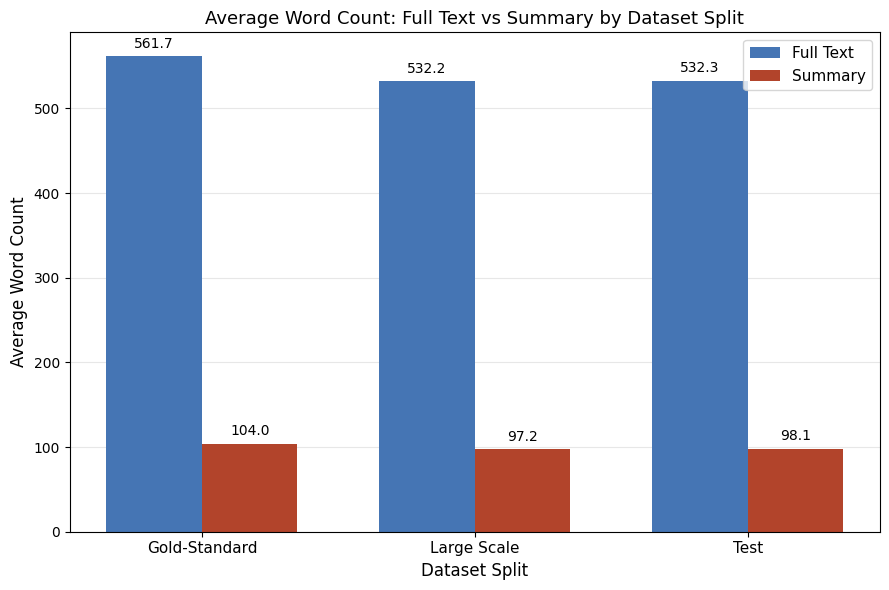

In [25]:
splits = ['Gold-Standard', 'Large Scale', 'Test']

avg_fulltext = [
    df_gs['Full_Text_Word_Count'].mean(),
    df_large['Full_Text_Word_Count'].mean(),
    df_test['Full_Text_Word_Count'].mean()
]

avg_summary = [
    df_gs['Summary_Word_Count'].mean(),
    df_large['Summary_Word_Count'].mean(),
    df_test['Summary_Word_Count'].mean()
]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(x - width/2, avg_fulltext, width, label='Full Text', color='#4575B4')
bars2 = ax.bar(x + width/2, avg_summary, width, label='Summary', color='#B2442B')

ax.bar_label(bars1, fmt='%.1f', padding=4, fontsize=10)
ax.bar_label(bars2, fmt='%.1f', padding=4, fontsize=10)

ax.set_xlabel('Dataset Split', fontsize=12)
ax.set_ylabel('Average Word Count', fontsize=12)
ax.set_title('Average Word Count: Full Text vs Summary by Dataset Split', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [26]:
# Check if any summary is ever longer than its full text counterpart
print(f"Gold-standard summaries longer than full text: {df_gs[df_gs['Summary_Word_Count'] > df_gs['Full_Text_Word_Count']].shape[0]}")
print(f"Large scale summaries longer than full text: {df_large[df_large['Summary_Word_Count'] > df_large['Full_Text_Word_Count']].shape[0]}")
print(f"Test summaries longer than full text: {df_test[df_test['Summary_Word_Count'] > df_test['Full_Text_Word_Count']].shape[0]}")

Gold-standard summaries longer than full text: 2
Large scale summaries longer than full text: 0
Test summaries longer than full text: 1


# Section 3: In-depth corpus analysis

We begin by tokenizing the full texts using the Llama 3.1 tokenizer and plotting its length distributions against window thresholds, to know how much of the corpus exceeds model input limits.

We then examine the compression rate distribution per split to understand how consistently the summaries are condensed across the corpus.

We evaluate word frequency across both full texts and summaries using word clouds.

Finally, we compute ROUGE-1 recall scores between each summary and its corresponding full text, to see the percentage of word overlap between them.

### Section 3.1: Token length distribution for the Llama 3.1 model

In [35]:
login()

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B")

# Tokenise all full texts using the LLama 3.1 tokeniser
df_gs["Token_Count"] = df_gs["Full_Text"].apply(lambda x: len(tokenizer.encode(x)))
df_large["Token_Count"] = df_large["Full_Text"].apply(lambda x: len(tokenizer.encode(x)))
df_test["Token_Count"] = df_test["Full_Text"].apply(lambda x: len(tokenizer.encode(x)))

thresholds = [512, 1024, 2048, 4096]
threshold_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False, sharex=True)

datasets = [
    (df_gs, 'Gold-Standard', '#4575B4'),
    (df_large, 'Large Scale', '#B2442B'),
    (df_test, 'Test', '#4DAC26'),
]

for ax, (df, title, color) in zip(axes, datasets):
    ax.hist(df["Token_Count"], bins=50, color=color, edgecolor='white', linewidth=0.5)
    for thresh, tcol in zip(thresholds, threshold_colors):
        ax.axvline(thresh, color=tcol, linestyle='--', linewidth=1.5, label=str(thresh))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Token Count", fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(title="Threshold", fontsize=9)

axes[0].set_ylabel("Number of Documents", fontsize=11)
fig.suptitle("Full Text Token Length Distribution (Llama 3.1 Tokenizer)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

for df, name in [(df_gs, "Gold-Standard"), (df_large, "Large-Scale"), (df_test, "Test")]:
    print(f"\n{name}")
    for thresh in thresholds:
        pct = (df["Token_Count"] > thresh).mean() * 100
        print(f"  > {thresh:>4} tokens: {pct:.1f}% of documents")

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B.
401 Client Error. (Request ID: Root=1-69e783e2-0f82900c39eabfd050c38fe2;0ca7b7f9-6d32-4879-a326-143a15f9f447)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B is restricted. You must have access to it and be authenticated to access it. Please log in.

### Section 3.2: Compression rate distribution

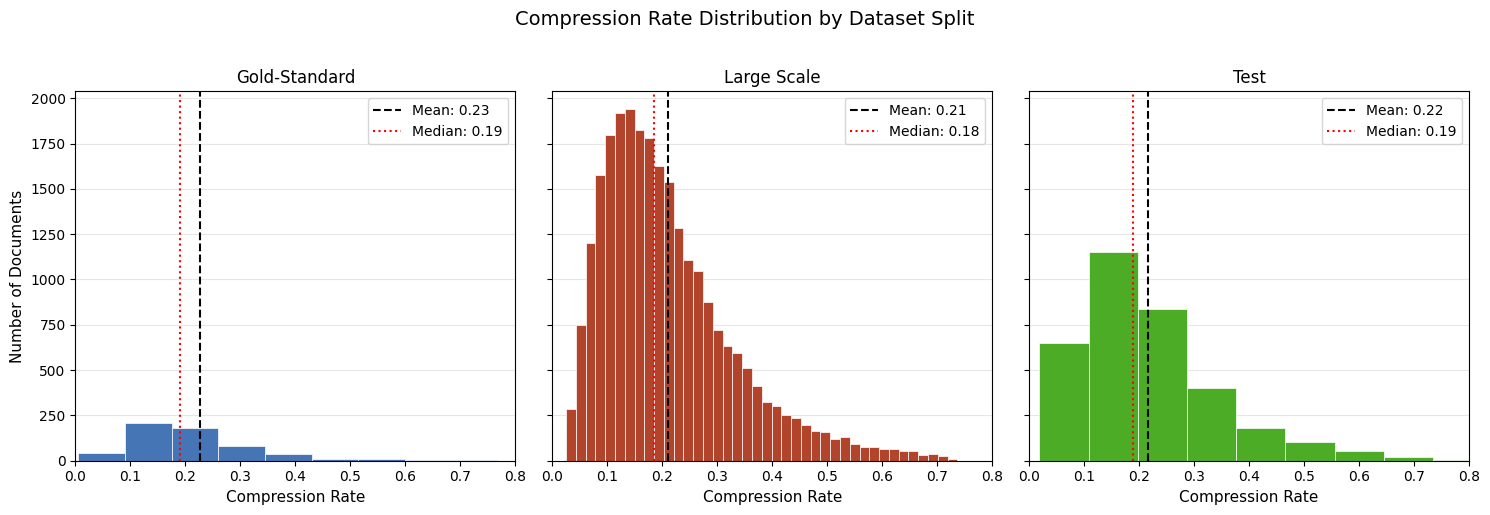

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

datasets = [
    (df_gs, 'Gold-Standard', '#4575B4'),
    (df_large, 'Large Scale', '#B2442B'),
    (df_test, 'Test', '#4DAC26'),
]

for ax, (df, title, color) in zip(axes, datasets):
    ax.hist(df['Compression_Rate'], bins=40, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df['Compression_Rate'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df["Compression_Rate"].mean():.2f}')
    ax.axvline(df['Compression_Rate'].median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {df["Compression_Rate"].median():.2f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Compression Rate', fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Number of Documents', fontsize=11)
fig.suptitle('Compression Rate Distribution by Dataset Split', fontsize=14, y=1.02)
# This is due to the outliers we discovered at the end of Section 2.3
axes[0].set_xlim(0, 0.8)
plt.tight_layout()
plt.show()

### Section 3.3: Word frequency evaluation

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leeze\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


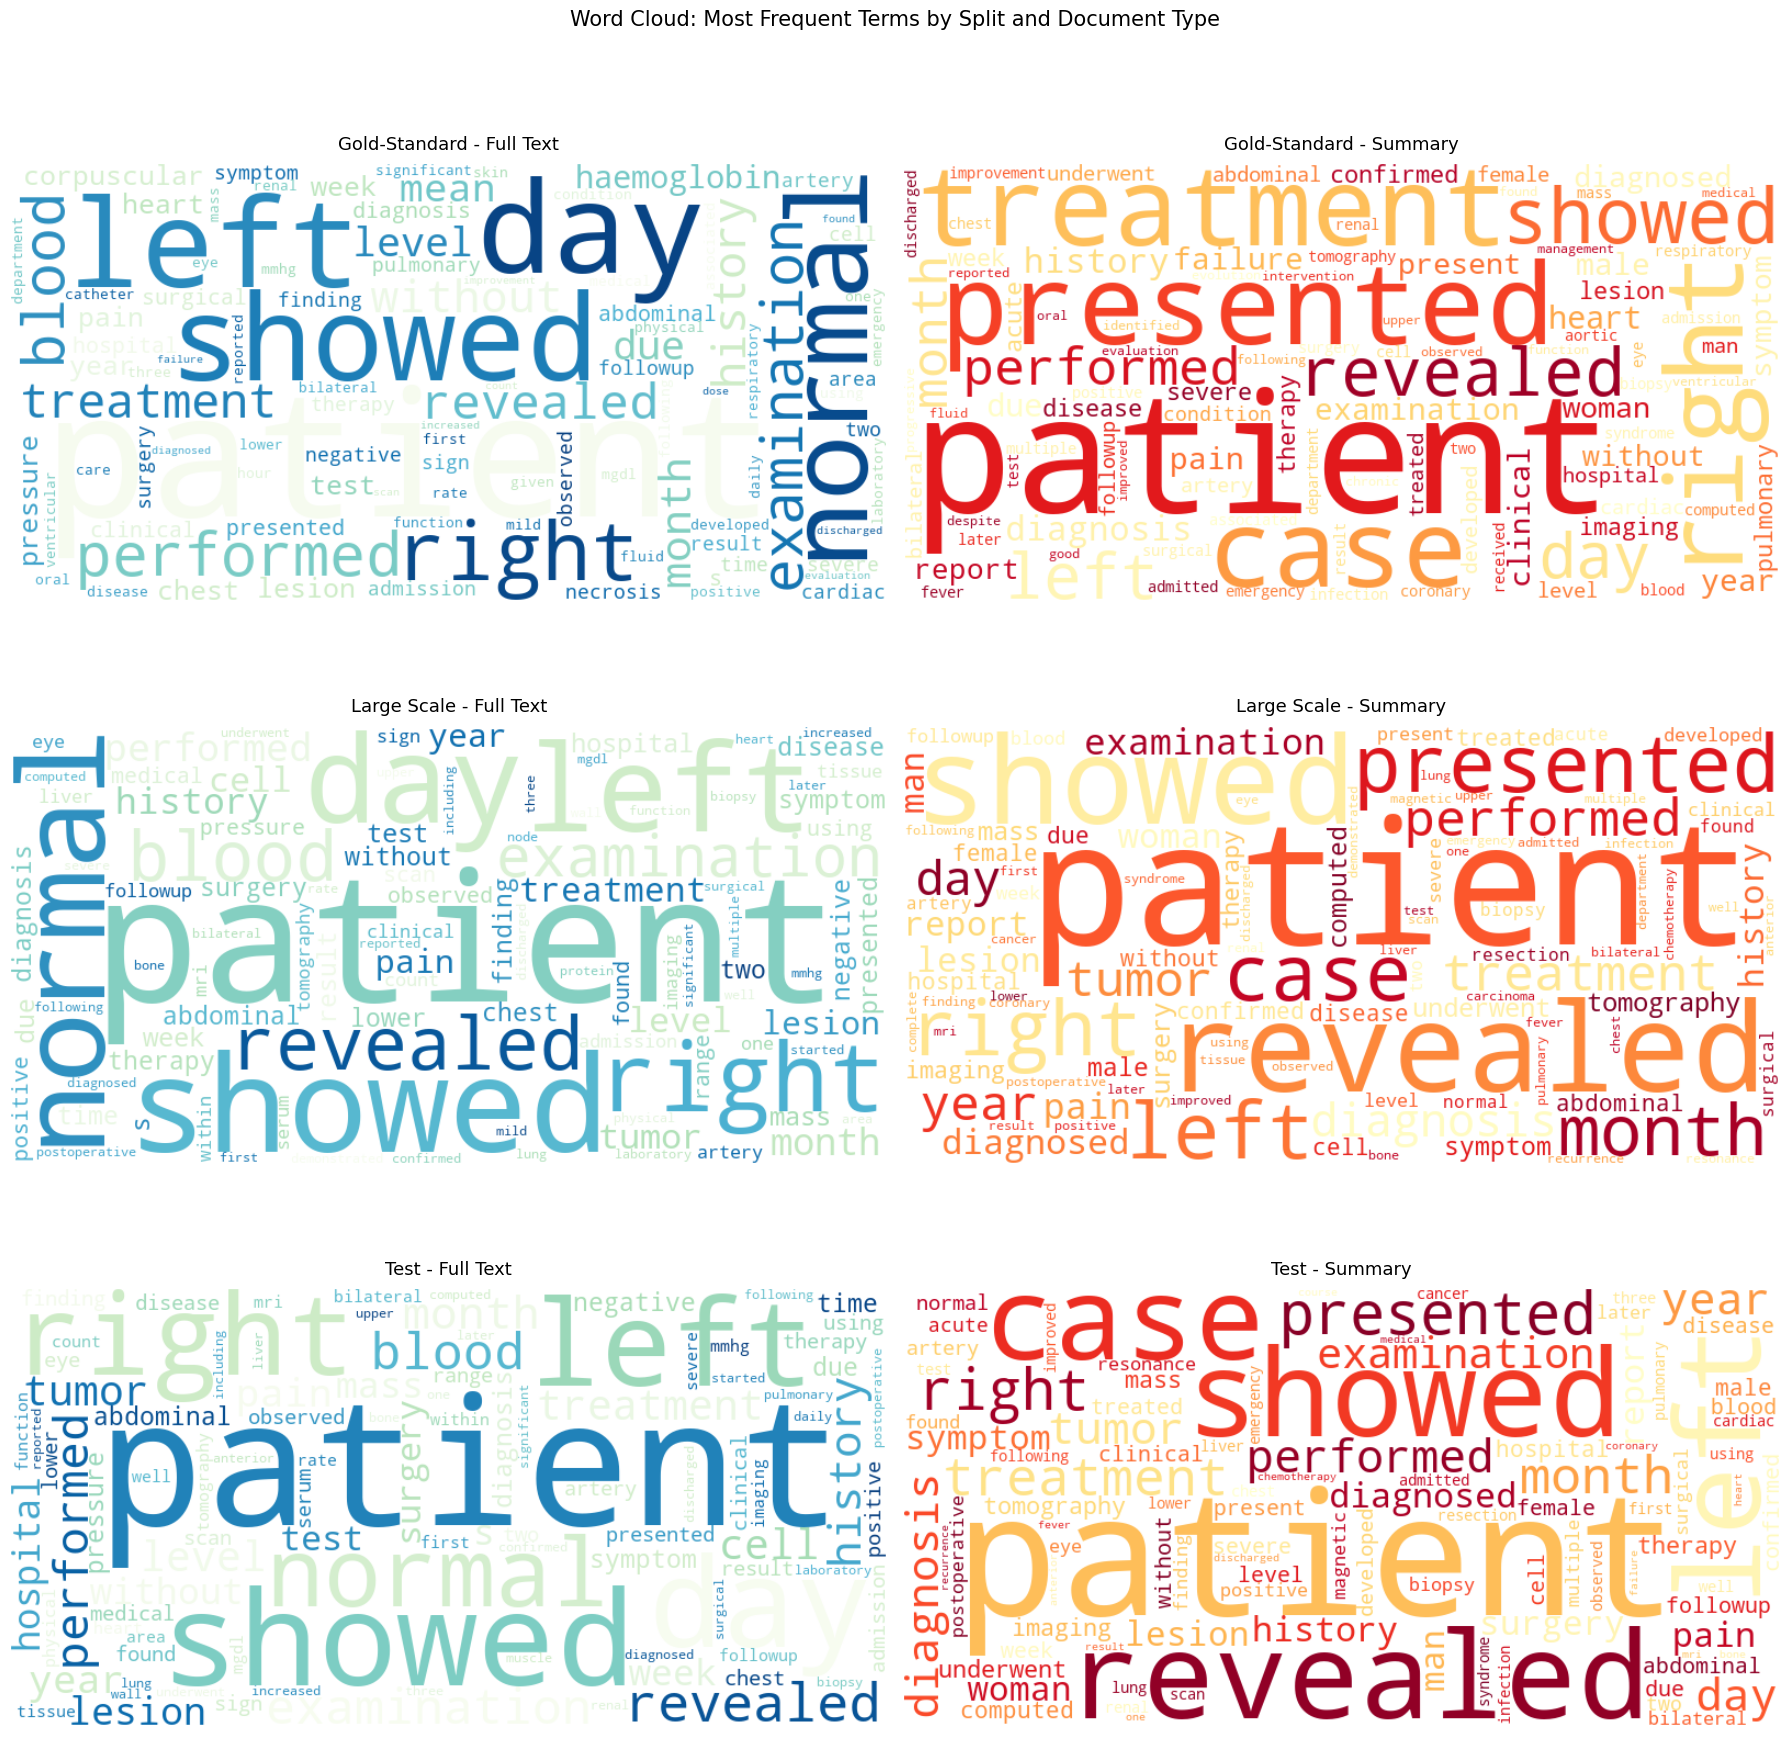

In [37]:
nltk.download('stopwords')

stop_words = set(nltk.corpus.stopwords.words('english'))

def get_clean_text(df, column):
    all_text = ' '.join(df[column].tolist()).lower()
    tokens = all_text.translate(str.maketrans('', '', string.punctuation)).split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

splits = {'Gold-Standard': df_gs, 'Large Scale': df_large, 'Test': df_test}

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for row_idx, (split_name, df) in enumerate(splits.items()):
    for col_idx, (column, label) in enumerate([('Full_Text', 'Full Text'), ('Summary', 'Summary')]):
        clean_text = get_clean_text(df, column)

        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='GnBu' if col_idx == 0 else 'YlOrRd',
            max_words=100,
            collocations=False
        ).generate(clean_text)

        ax = axes[row_idx][col_idx]
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{split_name} - {label}', fontsize=13, pad=10)

fig.suptitle('Word Cloud: Most Frequent Terms by Split and Document Type', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Section 3.4: ROUGE-1 metrics

In [38]:
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)

def compute_rouge1_recall(df):
    scores = []
    for _, row in df.iterrows():
        score = scorer.score(row['Full_Text'], row['Summary'])
        scores.append(score['rouge1'].recall)
    return scores

df_gs['ROUGE1_Recall'] = compute_rouge1_recall(df_gs)
df_large['ROUGE1_Recall'] = compute_rouge1_recall(df_large)
df_test['ROUGE1_Recall'] = compute_rouge1_recall(df_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False, sharex=True)

datasets = [
    (df_gs, 'Gold-Standard', '#4575B4'),
    (df_large, 'Large Scale', '#B2442B'),
    (df_test, 'Test', '#4DAC26'),
]

for ax, (df, title, color) in enumerate(datasets):
    axes[ax].hist(df['ROUGE1_Recall'], bins=40, color=color,
                  edgecolor='white', linewidth=0.5)
    axes[ax].axvline(df['ROUGE1_Recall'].mean(), color='black',
                     linestyle='--', linewidth=1.5,
                     label=f'Mean: {df["ROUGE1_Recall"].mean():.3f}')
    axes[ax].axvline(df['ROUGE1_Recall'].median(), color='red',
                     linestyle=':', linewidth=1.5,
                     label=f'Median: {df["ROUGE1_Recall"].median():.3f}')
    axes[ax].set_title(title, fontsize=12)
    axes[ax].set_xlabel('ROUGE-1 Recall', fontsize=11)
    axes[ax].yaxis.grid(True, alpha=0.3)
    axes[ax].set_axisbelow(True)
    axes[ax].legend(fontsize=10)

axes[0].set_ylabel('Number of Documents', fontsize=11)
fig.suptitle('ROUGE-1 Recall Distribution: Summary vs Full Text',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

# Section 4: Conclusion & limitations

# References